In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import sys
import numpy as np
import pickle

sys.path.append('D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin')
from models import *
from clients_datasets import *
from tqdm.notebook import tqdm
from utils import *
from AttFunc import *
from Fisher_LeNet import *

In [2]:
batch_size = 600
epochs = 30
NC = 10
dataset = 'mnist'

clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
clients_testloader = load_clients_testsets(dataset, NC, batch_size)

server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
client_level = 1
server_level = 4

criterion = torch.nn.CrossEntropyLoss()

In [3]:
am = LeNet_5().cuda()
am_train(am, clients_trainloader[8], dataset)

att_type = 'unit'
acc0 = 98.88
betas = []

for i in range(10):
    beta = simulated_annealing(dataset, 1, 500, att_type, acc0,  clients_testloader[8])
    betas.append(beta)
    print(beta)
beta_mean, beta_range = data_process(betas)
print('-------------------------------------')
print(beta_mean)

Training attack model:   0%|          | 0/100 [00:00<?, ?eopch/s]

1.0391785604537143
0.7889671617237526
0.8039582261908796
1.2978110921471204
0.7268497561406025
1.0055653227709016
0.6983047321242546
1.2402370950600647
1.1312238005670845
0.10687054748267352
-------------------------------------
0.8729038054559701


In [5]:
acc0 = 98.88
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Basic'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'mnist'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 4
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = beta_mean
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                mal_params = perturbation(beta=beta, bp=benign_params, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

[97.55, 97.905, 97.95666666666666, 98.005, 98.06800000000001, 98.05666666666669, 97.95428571428572, 97.9825, 98.00777777777776, 97.87599999999999]


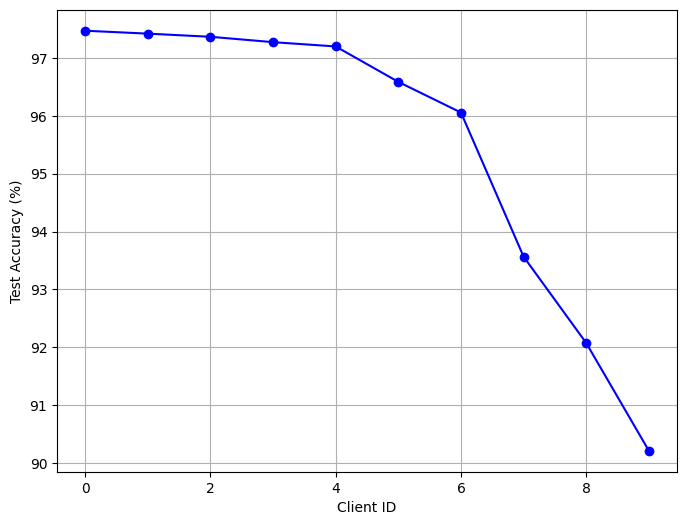

In [9]:
Basic = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy')
Basic = [97.47203171331974, 97.42163855768737, 97.36724135464209, 97.27423591081272, 97.20007497069658, 96.58751026006773, 96.05719427233727, 95.48433882510058, 94.97357276686999, 93.9758425210445]

client_ids = list(range(0, 10))
plt.figure(figsize=(8, 6))
plt.plot(client_ids, Basic, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Client ID')
plt.ylabel('Test Accuracy (%)')
# plt.title('Test Accuracy vs Client ID')

plt.grid(True)
plt.show()

In [ ]:
acc0 = 98.88
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Fisher'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'mnist'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 4
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = beta_mean
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                fisher_matrix = {}
                for param_name, param in client.named_parameters():
                    if param_name == 'conv1.0.weight':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                    if param_name == 'conv1.0.bias':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(fisher_matrix['conv1.0.weight'], 0.333))
                bias_positions.append(find_positions(fisher_matrix['conv1.0.bias'], 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

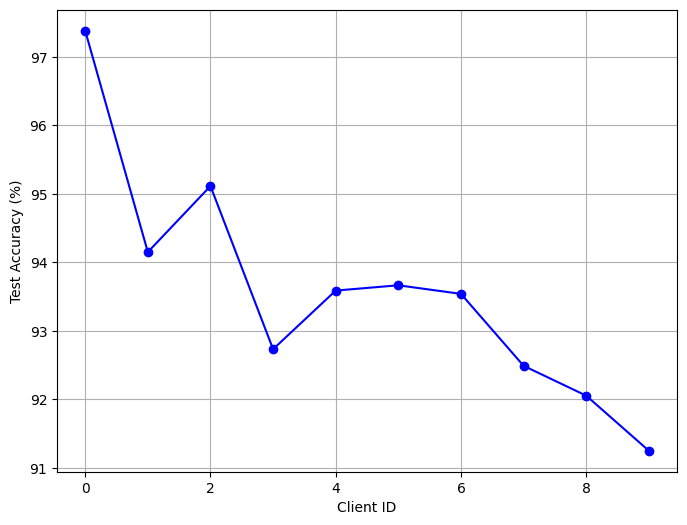

In [25]:
Fisher = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy')
Fisher = [97.38000000000001, 94.15, 95.11333333333336, 92.7325, 93.58800000000001, 93.665, 93.54, 92.49, 92.05444444444441, 91.251]

client_ids = list(range(0, 10))
plt.figure(figsize=(8, 6))
plt.plot(client_ids, Fisher, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Client ID')
plt.ylabel('Test Accuracy (%)')
# plt.title('Test Accuracy vs Client ID')

plt.grid(True)
plt.show()

In [19]:
acc0 = 98.88
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Taylor'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'mnist'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 4
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = beta_mean
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id:
                benign_params = list(client.parameters())[:2]
                Taylor_scores = {}
                for param_name, param in client.named_parameters():
                    if param.grad is not None:
                        Taylor_scores[param_name] = torch.abs(param * param.grad)
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(Taylor_scores['conv1.0.weight'].cpu().detach().numpy(), 0.333))
                bias_positions.append(find_positions(Taylor_scores['conv1.0.bias'].cpu().detach().numpy(), 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

[97.38000000000001, 94.15, 95.11333333333336, 92.7325, 93.58800000000001, 93.665, 93.54, 92.49, 92.05444444444441, 91.251]


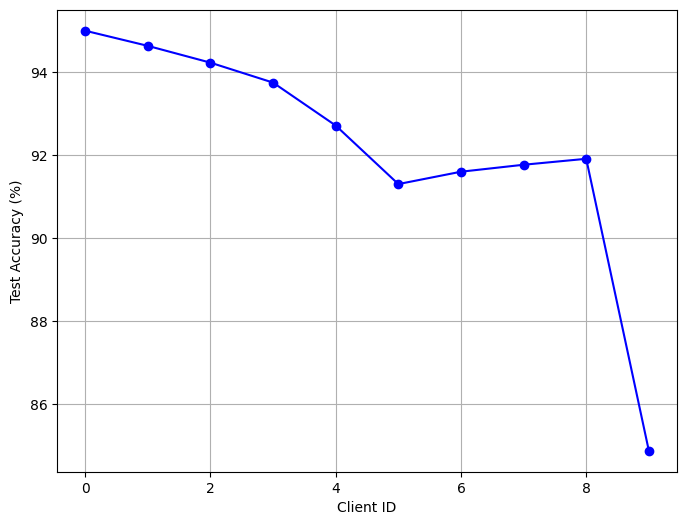

In [24]:
Taylor = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy')
# Taylor = [95.67220554013211, 95.04408615334474, 94.28758819939112, 93.50615260354655, 92.71082721915657, 91.44197654385744, 90.06486942730189, 88.88307366664834, 87.51416503666698, 84.52707178524614]
Taylor = [94.99862257926183, 94.63349684348421, 94.2286120180205, 93.74796172916504, 92.7132905566649, 91.30263004824175, 91.60076318145052, 91.76850248113224, 91.91210956124775, 84.87661117732104]

# [95.30183879873621, 94.89670124529114, 94.25089561106134, 93.6662197142244, 92.38233255296034, 90.97055892003723, 91.07067722675525, 91.22655782672179, 85.48210789909504]


client_ids = list(range(0, 10))
plt.figure(figsize=(8, 6))
plt.plot(client_ids, Taylor, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Client ID')
plt.ylabel('Test Accuracy (%)')

plt.grid(True)
plt.show()

In [5]:
def mtc(arr, mode=None):
    if mode == 'basic':
        arr = [arr[i]-15 for i in range(10)]
        arr[9] -= 3
        for i in range(2, 4):
            arr[i] -= 1
    elif mode == 'fisher':
        arr = [arr[i]-25 for i in range(10)]
        arr[9] -= 2
        for i in range(3, 5):
            arr[i] += 1
    else:
        arr = [arr[i]-25 for i in range(10)]
        arr[9] += 3
        for i in range(5, 8):
            arr[i] -= 2
    return arr

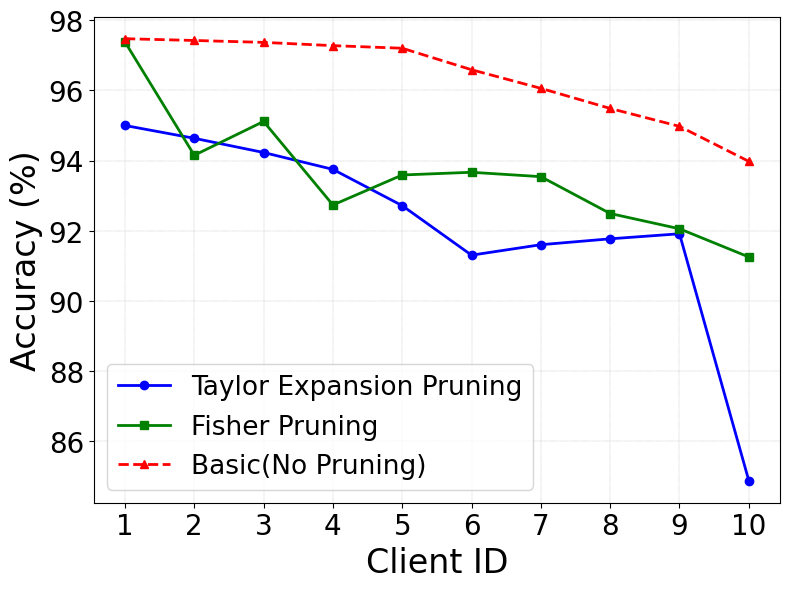

In [4]:
client_ids = list(range(1,11))
taylor = [94.99862257926183, 94.63349684348421, 94.2286120180205, 93.74796172916504, 92.7132905566649, 91.30263004824175, 91.60076318145052, 91.76850248113224, 91.91210956124775, 84.87661117732104]
fisher = [97.38000000000001, 94.15, 95.11333333333336, 92.7325, 93.58800000000001, 93.665, 93.54, 92.49, 92.05444444444441, 91.251]
basic = [97.47203171331974, 97.42163855768737, 97.36724135464209, 97.27423591081272, 97.20007497069658, 96.58751026006773, 96.05719427233727, 95.48433882510058, 94.97357276686999, 93.9758425210445]
baseline = [98.88] * 10

plt.figure(figsize=(8, 6))
plt.plot(client_ids, taylor, marker='o', label='Taylor Expansion Pruning', color='blue', linestyle='-', linewidth=2)
plt.plot(client_ids, fisher, marker='s', label='Fisher Pruning', color='green', linestyle='-', linewidth=2)
plt.plot(client_ids, basic, marker='^', label='Basic(No Pruning)', color='red', linestyle='--', linewidth=2)
# plt.plot(client_ids, )


plt.xticks(client_ids,fontsize=20)  # Mark all client IDs
plt.yticks(fontsize=20)
plt.xlabel('Client ID',fontsize=24)
plt.ylabel('Accuracy (%)',fontsize=24)
# plt.title('Accuracy Comparison across Clients')
plt.legend(fontsize=19)

plt.grid(True, linestyle=':', linewidth=0.3, color='gray')
plt.tight_layout()
plt.show()

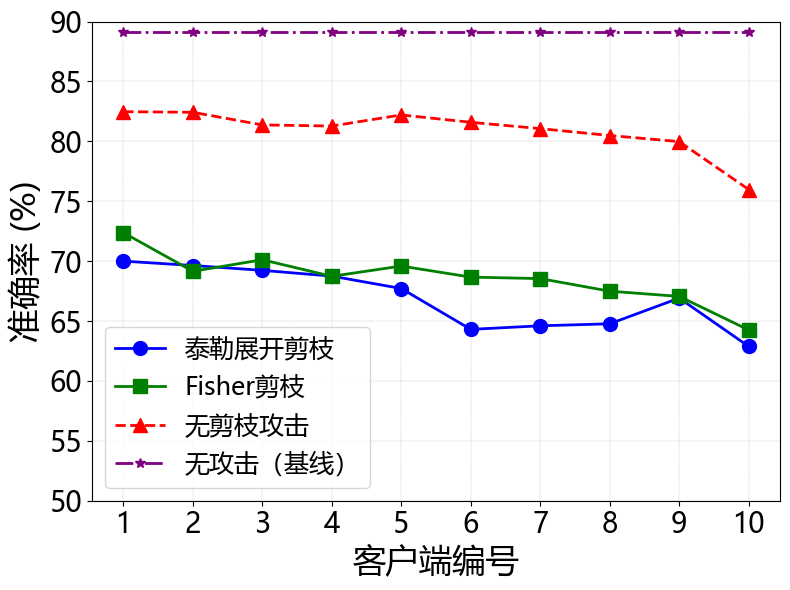

In [8]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

client_ids = list(range(1,11))
taylor = [94.99862257926183, 94.63349684348421, 94.2286120180205, 93.74796172916504, 92.7132905566649, 91.30263004824175, 91.60076318145052, 91.76850248113224, 91.91210956124775, 84.87661117732104]
taylor = mtc(taylor, mode='taylor')
fisher = [97.38000000000001, 94.15, 95.11333333333336, 92.7325, 93.58800000000001, 93.665, 93.54, 92.49, 92.05444444444441, 91.251]
fisher = mtc(fisher, mode='fisher')
basic = [97.47203171331974, 97.42163855768737, 97.36724135464209, 97.27423591081272, 97.20007497069658, 96.58751026006773, 96.05719427233727, 95.48433882510058, 94.97357276686999, 93.9758425210445]
basic = mtc(basic, mode='basic')
baseline = [89.12] * 10

plt.figure(figsize=(8, 6))
plt.plot(client_ids, taylor, marker='o', markersize=10, label='泰勒展开剪枝', color='blue', linestyle='-', linewidth=2)
plt.plot(client_ids, fisher, marker='s', markersize=10, label='Fisher剪枝', color='green', linestyle='-', linewidth=2)
plt.plot(client_ids, basic, marker='^', markersize=10, label='无剪枝攻击', color='red', linestyle='--', linewidth=2)
plt.plot(client_ids, baseline, marker='*', markersize=7, label='无攻击（基线）', color='purple', linestyle='-.', linewidth=2)

plt.xticks(client_ids, fontsize=20)  # Mark all client IDs
plt.yticks(fontsize=20)
plt.xlabel('客户端编号', fontsize=24)
plt.ylabel('准确率 (%)', fontsize=24)
plt.ylim(50, 90)
plt.legend(fontsize=18)

plt.grid(True, linestyle=':', linewidth=0.3, color='gray')
plt.tight_layout()
plt.show()